In [ ]:
!git clone -q https://github.com/svijaymurugan/BECSimulation.git
%cd BECSimulation
%load_ext autoreload
%autoreload 2

In [12]:
%load_ext autoreload
%autoreload 2
import torch
from config import SimulationConfig
from pprint import pprint

device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = SimulationConfig(
    # --- required: no defaults, you must state these ---
    Np=1e5,                       # particle number
    m=1.9e-25,                    # atomic mass (kg)
    omega=2 * torch.pi * 40,      # trap frequency (rad/s)
    a0=2e-9,                      # s-wave scattering length (m)
    a02=5e-25,                    # scattering volume, g2 term (m^3)
    up=2.5e-5,                    # half box length (m)
    N=256,                        # grid points in x and y

    # --- geometry ---
    Nz=None,                      # None means same as N
    sigma=10e-6,                  # width of the Gaussian ansatz (m)
    init_type="Gaussian",        # "Ground State" or "Gaussian"

    # --- trap ---
    gamma=1.0,                    # z anisotropy, real time
    imag_gamma=1.0,               # z anisotropy, imaginary time
    modulation_amp=0.0,
    modulation_freq=0.0,

    # --- real time ---
    ev_time=0.015,
    time_steps=100,

    # --- imaginary time ---
    imag_dtau=1e-4,
    imag_max_steps=15_000,
    tolerance=1e-6,

    # --- numerics ---
    cutoff="Hard Cutoff",         # see the registry in cutoff.py
    cutoff_coeff=0.3,
    include_g0=True,
    include_g2=True,
    high_precision=True,

    # --- what to record (all opt-in; see "Diagnostics" below) ---
    track_waist=False,
    track_modes=False,
)

#pprint(cfg)                        # dataclass prints every field, labelled
#pprint(cfg.to_dict()["_derived"])  # l, dt, G0, G2, ...

cfg.print_summary()  # prints only the most important fields

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
SimulationConfig

Physical
  particle number                100000
  atomic mass                   1.9e-25 kg
  trap frequency                     40 Hz       (omega = 251.3 rad/s)
  scattering length                   2 nm
  scattering volume               5e-25 m^3

Scales
  oscillator length l           1.48608 um
  trap period tau               3.97887 ms
  G0                            1691.21          contact, unitless
  G2                           0.642143          quadrupole, unitless

Grid
  points (N, N, nz)      256 x 256 x 256
  half box                           25 um       = 16.82 l
  spacing dx                   0.131428 l        OK
  ansatz sigma                       10 um       = 6.73 l

Real time
  duration                           15 ms
  steps                             100
  dt                                150 us       = 0.0377 tau
  z anisotropy gamma                  1
 

In [23]:
1 / ((torch.pi / grid.dx) / 10e6)

0.6216989964527124

In [ ]:
from grid import Grid
from cutoff import make_cutoff
from interactions import make_terms
from potentials import make_potential
from evolution import RealTimeEvolution, ImaginaryTimeEvolution
from diagnostics import Recorder, NormMonitor
import storage, plotting

grid   = Grid(cfg, device)
cutoff = make_cutoff(cfg, grid)
terms  = make_terms(cfg, grid, cutoff)
names  = [t.name for t in terms]

psi = grid.gaussian()
rec = Recorder(names,
               measure_every=10,          # energies every 10th step
               dt=cfg.dt,
               track_modes=cfg.track_modes,
               track_frames=True,         # for the GIF
               radius_squared=grid.radius_squared() if cfg.track_waist else None,
               dV=grid.dV)

xi = grid.healing_length(psi)
print(f"xi = {xi:.3f} l   dx = {grid.dxu:.3f} l   dx/xi = {grid.dxu/xi:.2f}")
if grid.dxu / xi > 1.0:
    warnings.warn(f"dx/xi = {grid.dxu/xi:.2f}: grid too coarse to resolve "
                  f"the healing length", RuntimeWarning)

print(f"kmax = {grid.kmax:e} l^-1")

g = grid.gaussian()
rho = torch.abs(g)**2
edge = max(rho[0].max(), rho[:, 0].max(), rho[:, :, 0].max()).item() / rho.max().item()
if edge > 1e-4:
    warnings.warn(f"initial state is {edge:.1e} of peak density at the box edge "
                  f"- the box truncates it", RuntimeWarning)

xi = 0.708 l   dx = 0.131 l   dx/xi = 0.19
kmax = 1.608495e+07 l^-1


In [ ]:
path = storage.ground_state_path(cfg)

if path.exists():
    psi, meta = storage.load_ground_state(path, cfg, device)
    print(f"Loaded ground state, E = {meta['final_energy']:.6f}, "
          f"{meta['steps']} steps, created {meta['created']}")
else:
    rec_ite = Recorder.energies_only(names, dt=cfg.imag_dtau)
    ite = ImaginaryTimeEvolution(
        grid, make_potential(cfg, grid, cfg.imag_gamma), terms,
        dtau=cfg.imag_dtau, max_steps=cfg.imag_max_steps,
        recorder=rec_ite, tolerance=cfg.tolerance)
    psi = ite.run(grid.gaussian().to(device))
    storage.save_ground_state(path, psi, cfg,
                              converged=ite.converged,
                              final_energy=rec_ite.last_total(),
                              steps=ite.steps_taken)

print(f"Computed and cached: {path}")

0.0 % Completed
Step 100: E = 23.816011, change = nan
Step 200: E = 18.538904, change = 2.216e-01
Step 300: E = 15.397716, change = 1.694e-01
Step 400: E = 13.365319, change = 1.320e-01
Step 500: E = 11.978160, change = 1.038e-01
Step 600: E = 10.996109, change = 8.199e-02
Step 700: E = 10.281972, change = 6.494e-02
Step 800: E = 9.751676, change = 5.158e-02
Step 900: E = 9.351021, change = 4.109e-02
Step 1000: E = 9.043745, change = 3.286e-02
Step 1100: E = 8.804908, change = 2.641e-02
Step 1200: E = 8.616984, change = 2.134e-02
Step 1300: E = 8.467443, change = 1.735e-02
Step 1400: E = 8.347195, change = 1.420e-02
Step 1500: E = 8.249558, change = 1.170e-02
Step 1600: E = 8.169563, change = 9.697e-03
Step 1700: E = 8.103474, change = 8.090e-03
Step 1800: E = 8.048452, change = 6.790e-03
Step 1900: E = 8.002315, change = 5.732e-03
Step 2000: E = 7.963374, change = 4.866e-03
Step 2100: E = 7.930307, change = 4.152e-03
Step 2200: E = 7.902072, change = 3.560e-03
Step 2300: E = 7.877838,

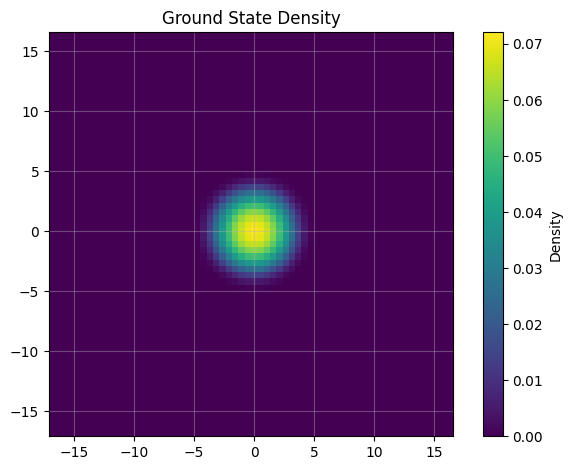

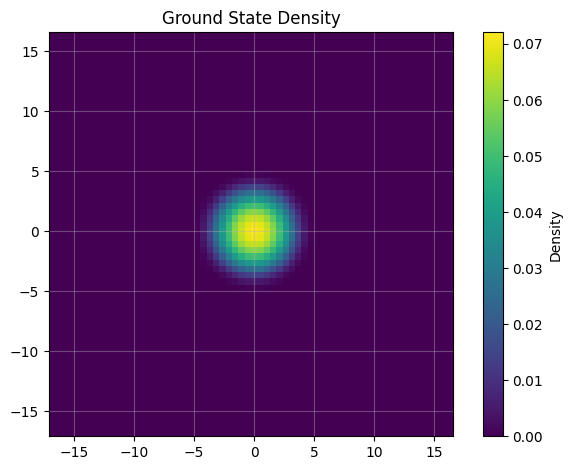

In [12]:
import torch
density = torch.abs(psi)**2
xy_density = torch.sum(density, dim=2).detach().to(torch.float32)
xz_density = torch.sum(density, dim=1).detach().to(torch.float32)

plotting.density_map(xy_density, grid.x/cfg.l, grid.x/cfg.l, title="Ground State Density");
plotting.density_map(xz_density, grid.x/cfg.l, grid.z/cfg.l, title="Ground State Density");


In [ ]:


rte = RealTimeEvolution(
    grid, make_potential(cfg, grid, cfg.gamma), terms,
    dtau=cfg.dtau, max_steps=cfg.time_steps,
    recorder=rec, measure_every=10,
    monitors=[NormMonitor(grid)])

psi_final = rte.run(grid.gaussian().to(device))

out = "storage/run_2026_09_19"
storage.save_run(out, cfg, grid, rec,
                 description="Test RTE on Ground State",
                 psi_final=psi_final.cpu().numpy())

#from google.colab import drive; drive.mount('/content/drive')
#out = "/content/drive/MyDrive/BECSimulation/storage"
storage.save_run(f"{out}/run_x", cfg, grid, rec)
storage.ground_state_path(cfg, root=out)

xi = 0.708 l   dx = 0.526 l   dx/xi = 0.74
0.0 % Completed
10.0 % Completed
20.0 % Completed
30.0 % Completed
40.0 % Completed
50.0 % Completed
60.0 % Completed
70.0 % Completed
80.0 % Completed
90.0 % Completed


PosixPath('storage/run_2026_09_19/ground_state_e2c70bff8697bd61.pt')

In [8]:
cfg_dict, arrays = storage.load_run(f"{out}/run_x/run.npz")

figs, gifs = plotting.standard_set(arrays, out_dir=f"{out}/plots")
figs["energies"]                                  # renders inline
#figs["energies"].axes[0].set_yscale("log")        # adjust after the fact
plotting.save_set(figs, f"{out}/plots")

[PosixPath('storage/run_2026_09_19/plots/energies.png')]

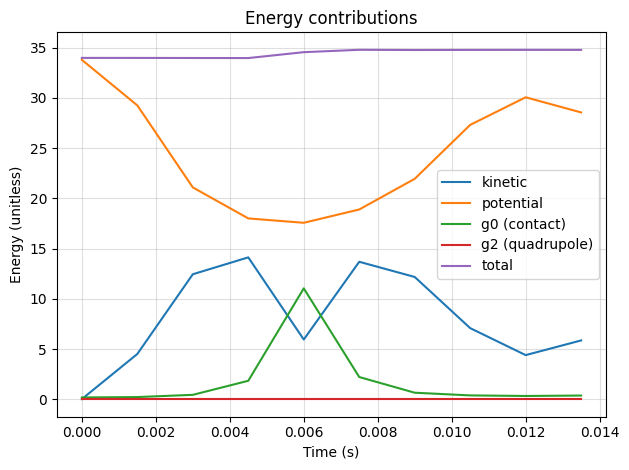

In [9]:
figs["energies"]

# Sweep Code

storage/sweep_2026_09_13/
  sweep.json              <- what you were trying to learn, and the base config
  run_gamma_0.8/run.npz   <- each carries its own full config
  run_gamma_0.9/run.npz
  ...

In [ ]:
# ============================================================================
# CELL: sweep machinery. Paste once, don't edit.
# ============================================================================
import json
import warnings
from dataclasses import replace
from datetime import datetime
from pathlib import Path

import numpy as np
import torch

from config import SimulationConfig
from grid import Grid
from cutoff import make_cutoff
from interactions import make_terms
from potentials import make_potential
from evolution import RealTimeEvolution, ImaginaryTimeEvolution
from diagnostics import Recorder, NormMonitor
import storage, plotting


def run_one(cfg, out_dir, *, description="", device="cuda", measure_every=10,
            track_frames=False, skip_if_done=True):
    """One full simulation: ground state (cached) then real time.

    Returns the output directory. If `run.npz` already exists there and
    skip_if_done is True, returns immediately without recomputing - so an
    interrupted sweep resumes rather than redoing finished points.
    """
    out = Path(out_dir)
    if skip_if_done and (out / "run.npz").exists():
        print(f"  skip (already done): {out.name}")
        return out

    grid   = Grid(cfg, device)
    cutoff = make_cutoff(cfg, grid)
    terms  = make_terms(cfg, grid, cutoff)
    names  = [t.name for t in terms]

    # --- ground state, from cache when the physics matches ---
    gs_path = storage.ground_state_path(cfg)
    if gs_path.exists():
        psi, meta = storage.load_ground_state(gs_path, cfg, device)
        print(f"  ground state from cache, E = {meta['final_energy']:.6f}")
    else:
        rec_ite = Recorder.energies_only(names, dt=cfg.imag_dtau)
        ite = ImaginaryTimeEvolution(
            grid, make_potential(cfg, grid, cfg.imag_gamma), terms,
            dtau=cfg.imag_dtau, max_steps=cfg.imag_max_steps,
            recorder=rec_ite, tolerance=cfg.tolerance)
        psi = ite.run(grid.gaussian().to(device))
        storage.save_ground_state(gs_path, psi, cfg, converged=ite.converged,
                                  final_energy=rec_ite.last_total(),
                                  steps=ite.steps_taken)
        print(f"  ground state computed in {ite.steps_taken} steps, cached")

    # --- resolution check, before spending real-time GPU hours ---
    xi = grid.healing_length(psi)
    if np.isfinite(xi):
        ratio = grid.dxu / xi
        print(f"  xi = {xi:.3f} l   dx = {grid.dxu:.3f} l   dx/xi = {ratio:.2f}")
        if ratio > 1.0:
            warnings.warn(f"dx/xi = {ratio:.2f}: grid too coarse to resolve "
                          f"the healing length", RuntimeWarning)

    # --- real time ---
    rec = Recorder(names,
                   measure_every=measure_every, dt=cfg.dt,
                   track_modes=cfg.track_modes,
                   track_frames=track_frames,
                   radius_squared=grid.radius_squared() if cfg.track_waist else None,
                   dV=grid.dV)
    rte = RealTimeEvolution(
        grid, make_potential(cfg, grid, cfg.gamma), terms,
        dtau=cfg.dtau, max_steps=cfg.time_steps,
        recorder=rec, measure_every=measure_every,
        monitors=[NormMonitor(grid)])
    psi_final = rte.run(psi)

    storage.save_run(out, cfg, grid, rec, description=description,
                     psi_final=psi_final.cpu().numpy())
    return out


def run_sweep(base_cfg, field, values, *, root, description,
              device="cuda", **run_kwargs):
    """Run one simulation per value of `field`.

    `description` describes the SWEEP - why you ran it, what you expect - and
    is written once to sweep.json. Each run's own identity lives in the config
    saved inside its run.npz, so per-run descriptions stay mechanical.

    Sweep directories use stable labels (not timestamps) so that re-running
    resumes rather than duplicating.
    """
    root = Path(root)
    root.mkdir(parents=True, exist_ok=True)

    (root / "sweep.json").write_text(json.dumps({
        "description": description,
        "swept_field": field,
        "values":      [float(v) for v in values],
        "base_config": base_cfg.to_dict(),
        "created":     datetime.now().isoformat(timespec="seconds"),
    }, indent=2, default=str))

    paths = {}
    for k, v in enumerate(values, 1):
        label = f"{field}_{v:.4g}"
        print(f"[{k}/{len(values)}] {label}")
        cfg_v = replace(base_cfg, **{field: v})      # validation re-runs here
        paths[float(v)] = run_one(cfg_v, root / label, device=device,
                                  description=f"{field} = {v:.6g}", **run_kwargs)
    return paths


def collect_sweep(root, extract):
    """Read a finished sweep back. `extract(cfg_dict, arrays) -> value`.

    Works months later with no GPU: everything needed is inside each run.npz.
    """
    root = Path(root)
    manifest = json.loads((root / "sweep.json").read_text())
    field = manifest["swept_field"]

    out = {}
    for d in sorted(root.iterdir()):
        npz = d / "run.npz"
        if not npz.exists():
            continue
        cfg_dict, arrays = storage.load_run(npz)
        value = cfg_dict[field]
        out[value] = extract(cfg_dict, arrays)
    return manifest, dict(sorted(out.items()))

In [ ]:
# ============================================================================
# CELL: the sweep. This is the only part you change.
# ============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = SimulationConfig(
    Np=1e5, m=1.9e-25, omega=2 * np.pi * 40,
    a0=2e-9, a02=5e-23,
    up=2.5e-5, N=256,
    sigma=10e-6, ev_time=0.015, time_steps=10_000,
    modulation_amp=0.1, modulation_freq=2 * 5**0.5,
    cutoff="Hard Cutoff", cutoff_coeff=0.9,
    track_waist=True, track_modes=True,
)
print(cfg)

paths = run_sweep(
    cfg,
    field="gamma",
    values=np.linspace(0.8, 1.4, 7),
    root="storage/sweep_20260917_gamma",
    description=(
        "Scanning trap anisotropy to find where the quadrupole mode goes soft. "
        "Following up on the k=2 feature in the 09-07 run. Expect the waist "
        "oscillation amplitude to peak near gamma = 1.1 if the resonance "
        "condition is what I think it is."
    ),
    device=device,
    measure_every=10,
)

In [ ]:
manifest, results = collect_sweep(
    "storage/sweep_20260917_gamma",
    extract=lambda cfg_d, a: a["waist"].max() - a["waist"].min(),
)

print(manifest["description"])

fig, ax = plt.subplots()
ax.plot(list(results), list(results.values()), "o-")
ax.set_xlabel(manifest["swept_field"])
ax.set_ylabel("waist oscillation amplitude")
ax.grid(True, alpha=0.4)

# Ignore Below: Golden Test

In [27]:
%load_ext autoreload
%autoreload 2

import torch
from config import SimulationConfig 
from grid import Grid
from cutoff import make_cutoff 
from interactions import make_terms
from potentials import make_potential 
from evolution import RealTimeEvolution, ImaginaryTimeEvolution
from diagnostics import Recorder, NormMonitor
import storage, plotting

device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = SimulationConfig(
    Np=1e5, m=1.9e-25, omega=2 * torch.pi * 40,
    a0=2e-9, a02=5e-23,
    up=7.5e-6, N=32,
    sigma=10e-6, ev_time=3e-4, time_steps=200,
    cutoff="Hard Cutoff", cutoff_coeff=0.9,
)

grid   = Grid(cfg, device)
cutoff = make_cutoff(cfg, grid)
terms  = make_terms(cfg, grid, cutoff)

rec = Recorder([t.name for t in terms], measure_every=10, track_modes=cfg.track_modes, dt = cfg.dtau, radius_squared=grid.radius_squared() if cfg.track_waist else None, dV=grid.dV)

rte = RealTimeEvolution(
    grid, make_potential(cfg, grid, cfg.gamma), terms,
    dtau=cfg.dtau, max_steps=cfg.time_steps,
    recorder=rec,
    monitors=[NormMonitor(grid)])

psi_final = rte.run(grid.gaussian().to(device))
storage.save_run("storage/run_2026_09_07", cfg, grid,
                 rec, psi_final=psi_final.cpu().numpy())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


PosixPath('storage/run_2026_09_07/run.npz')

In [35]:
import numpy as np

base = np.load("../baseline_small.npz")

def compare(name, new, old, rtol=1e-12, atol=None):
    new, old = np.asarray(new), np.asarray(old)
    if atol is None:
        atol = 1e-15 * np.max(np.abs(old))   # floor relative to the array's scale
    ok = np.allclose(new, old, rtol=rtol, atol=atol)
    signif = np.abs(old) > atol              # ignore entries that are numerically zero
    worst = (np.max(np.abs(new[signif] - old[signif]) / np.abs(old[signif]))
             if signif.any() else 0.0)
    print(f"{name:12s} {'PASS' if ok else 'FAIL'}   worst rel diff = {worst:.3e} "
          f"(atol={atol:.2e}, {(~signif).sum()} near-zero entries skipped)")
    return ok

compare("psi_final", psi_final.cpu().numpy(), base["psi_final"])
compare("energies",  rec.energies(),        base["energies"])
#compare("kx",        rec.modes()[0],        base["kx"])

psi_final    PASS   worst rel diff = 1.851e-14 (atol=4.06e-17, 0 near-zero entries skipped)
energies     FAIL   worst rel diff = 7.635e-03 (atol=1.18e-14, 1 near-zero entries skipped)


False